# Exploratory Data Analysis - Airline Performance 2025

## Business question

**What causes flight delays and cancellations, and how can airlines and airports improve operational performance?**

This notebook analyses all US domestic flights reported in 2025. The dataset is read in chunks because it contains more than 7 million rows.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

DATA_FILE = "flights_2025_cleaned.zip"

CHUNK_SIZE = 250_000
plt.style.use("seaborn-v0_8-whitegrid")

## 1. Prepare summary tables

In [2]:
columns = [
    "month", "day_of_week", "airline_name", "origin", "dest", "route",
    "departure_hour", "time_of_day", "flight_status", "cancelled",
    "diverted", "on_time", "delayed", "dep_delay", "arr_delay",
    "carrier_delay", "weather_delay", "n_a_s_delay",
    "security_delay", "late_aircraft_delay"
]

value_columns = [
    "total_flights", "completed_flights", "on_time", "delayed",
    "cancelled", "diverted", "arrival_delay_total", "arrival_delay_count",
    "departure_delay_total", "departure_delay_count", "carrier_delay",
    "weather_delay", "n_a_s_delay", "security_delay", "late_aircraft_delay"
]

groups = {
    "airline": "airline_name",
    "origin_airport": "origin",
    "destination_airport": "dest",
    "route": "route",
    "month": "month",
    "weekday": "day_of_week",
    "departure_hour": "departure_hour",
    "time_of_day": "time_of_day",
}

parts = {name: [] for name in groups}
overall_parts = []

In [3]:
for chunk in pd.read_csv(DATA_FILE, usecols=columns, chunksize=CHUNK_SIZE):
    chunk["total_flights"] = 1
    chunk["completed_flights"] = chunk["flight_status"].isin(["On Time", "Delayed"]).astype(int)
    chunk["arrival_delay_total"] = chunk["arr_delay"].fillna(0)
    chunk["arrival_delay_count"] = chunk["arr_delay"].notna().astype(int)
    chunk["departure_delay_total"] = chunk["dep_delay"].fillna(0)
    chunk["departure_delay_count"] = chunk["dep_delay"].notna().astype(int)

    overall_parts.append(chunk[value_columns].sum())

    for name, group_column in groups.items():
        summary = chunk.groupby(group_column)[value_columns].sum()
        parts[name].append(summary)

print("All chunks processed")

In [4]:
def finish_summary(summary_parts):
    result = pd.concat(summary_parts).groupby(level=0).sum()
    result["on_time_rate"] = result["on_time"] / result["completed_flights"] * 100
    result["delay_rate"] = result["delayed"] / result["completed_flights"] * 100
    result["cancellation_rate"] = result["cancelled"] / result["total_flights"] * 100
    result["average_arrival_delay"] = result["arrival_delay_total"] / result["arrival_delay_count"]
    result["average_departure_delay"] = result["departure_delay_total"] / result["departure_delay_count"]
    return result.reset_index()


summaries = {name: finish_summary(table_parts) for name, table_parts in parts.items()}
overall = pd.DataFrame(overall_parts).sum()

print("Summary tables ready")

## 2. Overall performance

In [5]:
overall_results = pd.Series({
    "Total Flights": int(overall["total_flights"]),
    "On-Time Arrival Rate (%)": overall["on_time"] / overall["completed_flights"] * 100,
    "Average Arrival Delay (min)": overall["arrival_delay_total"] / overall["arrival_delay_count"],
    "Cancelled Flights": int(overall["cancelled"]),
    "Cancellation Rate (%)": overall["cancelled"] / overall["total_flights"] * 100,
    "Diverted Flights": int(overall["diverted"]),
})

overall_results.round(2)

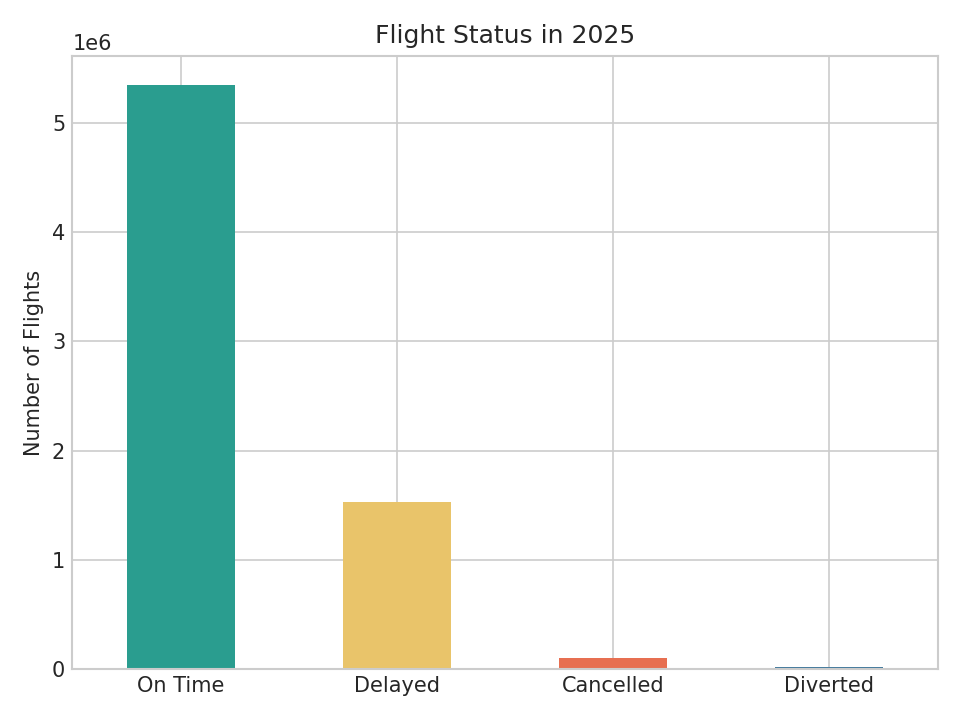

In [6]:
status_counts = pd.Series({
    "On Time": int(overall["on_time"]),
    "Delayed": int(overall["delayed"]),
    "Cancelled": int(overall["cancelled"]),
    "Diverted": int(overall["diverted"]),
})

status_counts.plot(kind="bar", color=["#2A9D8F", "#E9C46A", "#E76F51", "#457B9D"])
plt.title("Flight Status in 2025")
plt.ylabel("Number of Flights")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 3. Monthly performance

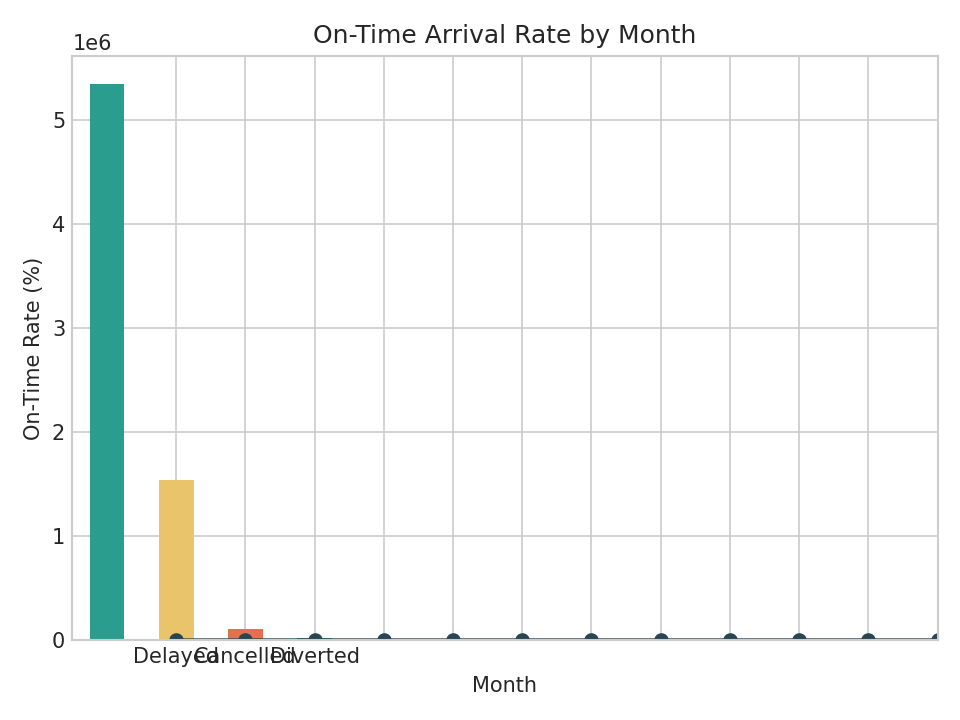

In [7]:
monthly = summaries["month"].sort_values("month")

plt.plot(monthly["month"], monthly["on_time_rate"], marker="o", color="#264653")
plt.title("On-Time Arrival Rate by Month")
plt.xlabel("Month")
plt.ylabel("On-Time Rate (%)")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

monthly[["month", "on_time_rate", "average_arrival_delay", "cancellation_rate"]].round(2)

## 4. Airline performance

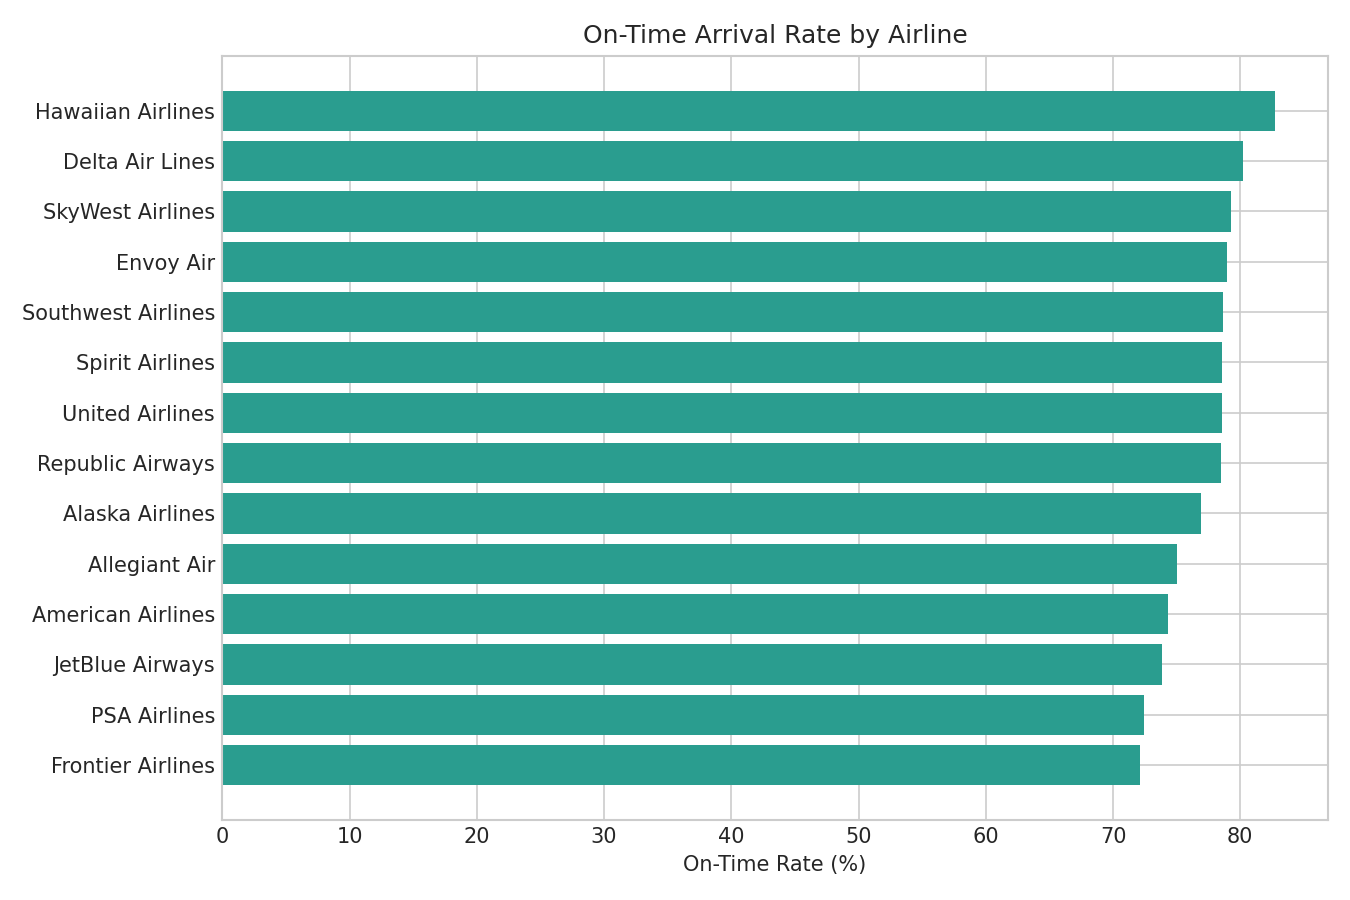

In [8]:
airlines = summaries["airline"].sort_values("on_time_rate", ascending=False)

plt.figure(figsize=(9, 6))
plt.barh(airlines["airline_name"], airlines["on_time_rate"], color="#2A9D8F")
plt.title("On-Time Arrival Rate by Airline")
plt.xlabel("On-Time Rate (%)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

airlines[["airline_name", "total_flights", "on_time_rate", "average_arrival_delay", "cancellation_rate"]].round(2)

## 5. Airport and route performance

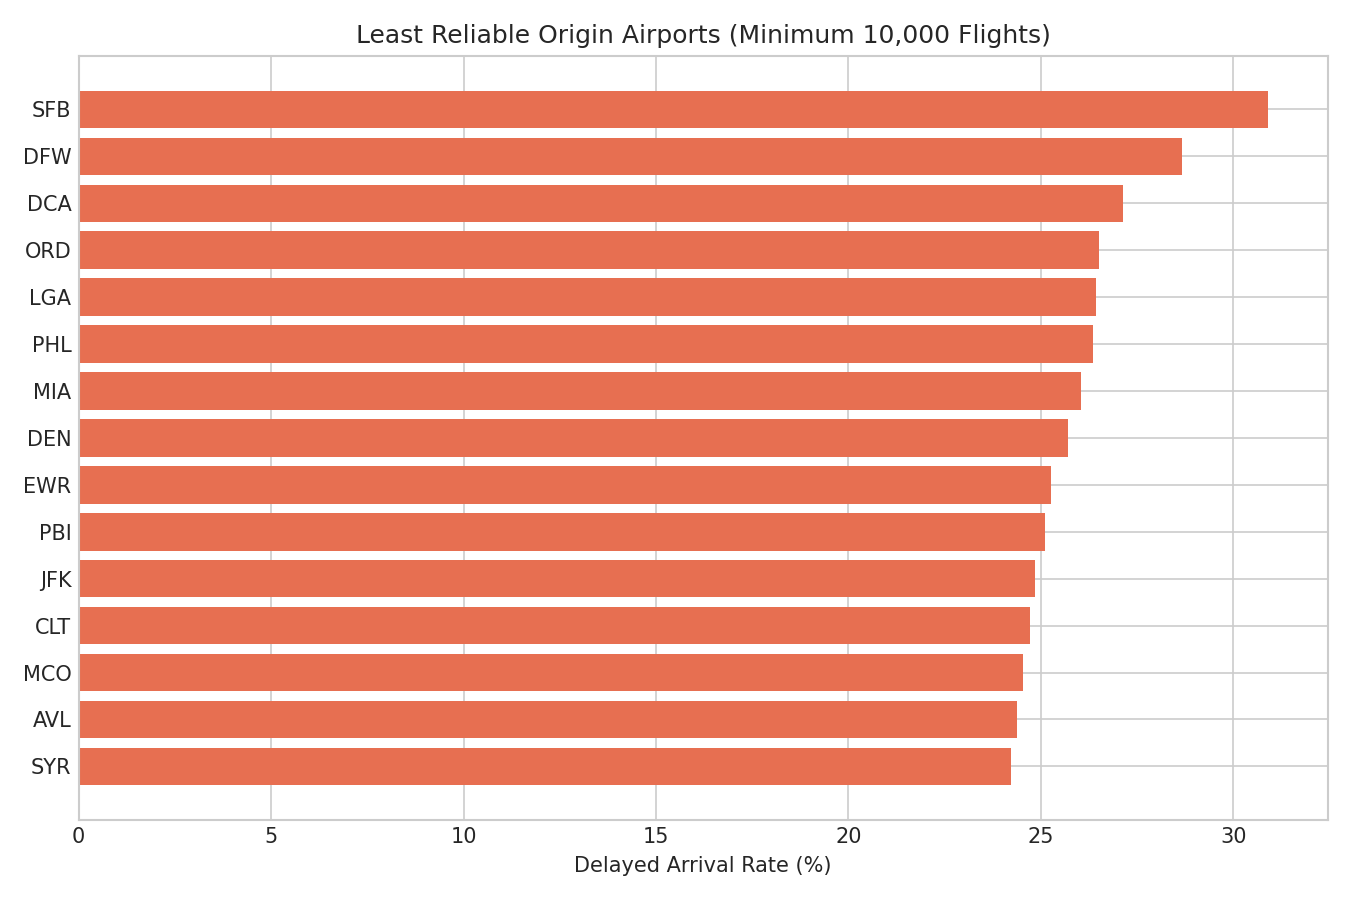

In [9]:
origins = summaries["origin_airport"]
busy_origins = origins[origins["total_flights"] >= 10_000]
worst_origins = busy_origins.nlargest(15, "delay_rate")

plt.figure(figsize=(9, 6))
plt.barh(worst_origins["origin"], worst_origins["delay_rate"], color="#E76F51")
plt.title("Least Reliable Origin Airports (Minimum 10,000 Flights)")
plt.xlabel("Delayed Arrival Rate (%)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

worst_origins[["origin", "total_flights", "delay_rate", "average_departure_delay", "cancellation_rate"]].round(2)

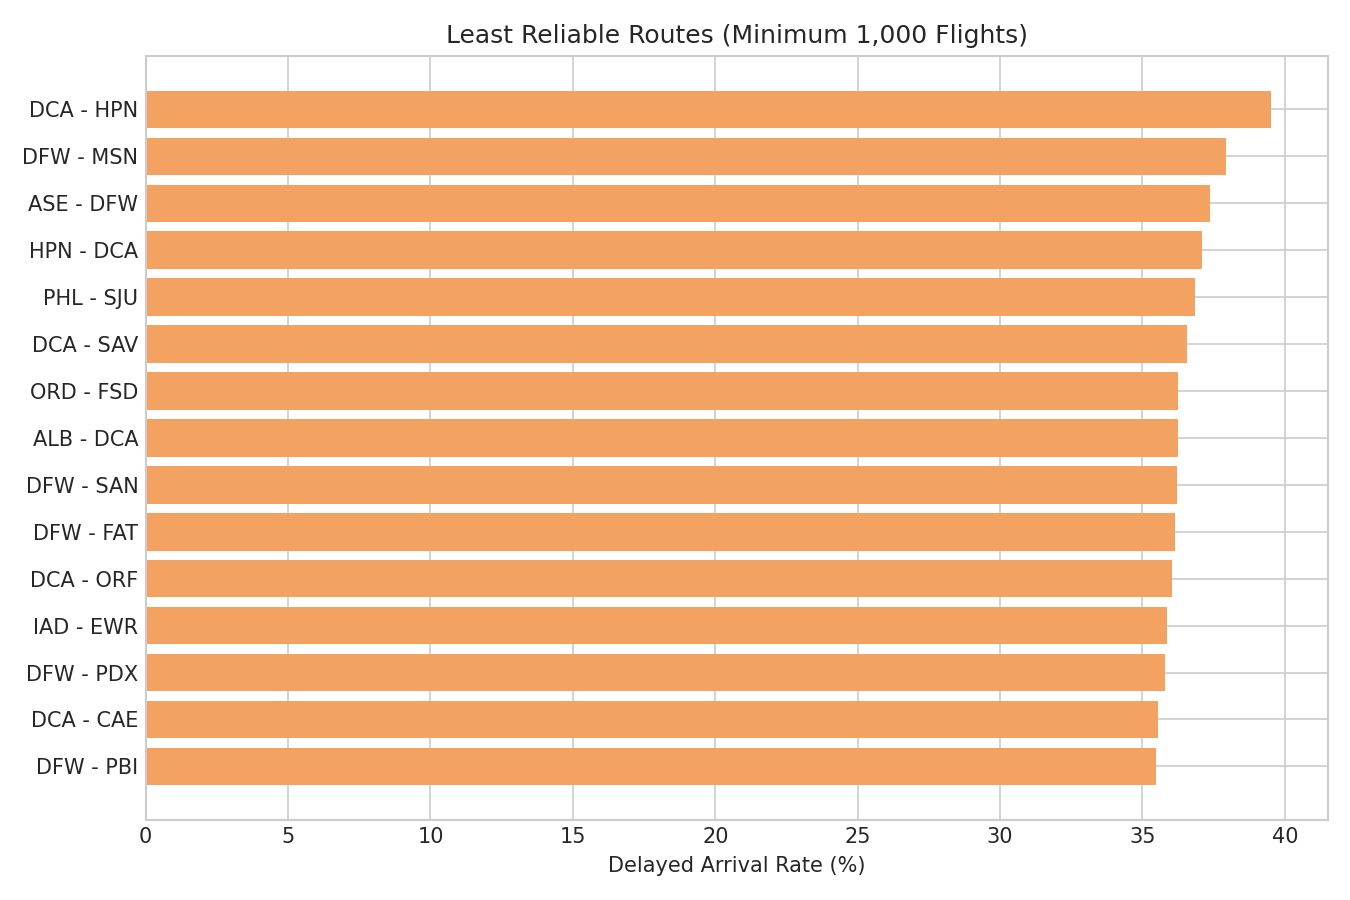

In [10]:
routes = summaries["route"]
busy_routes = routes[routes["total_flights"] >= 1_000]
worst_routes = busy_routes.nlargest(15, "delay_rate")

plt.figure(figsize=(9, 6))
plt.barh(worst_routes["route"], worst_routes["delay_rate"], color="#F4A261")
plt.title("Least Reliable Routes (Minimum 1,000 Flights)")
plt.xlabel("Delayed Arrival Rate (%)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

worst_routes[["route", "total_flights", "delay_rate", "average_arrival_delay", "cancellation_rate"]].round(2)

## 6. Time analysis and delay propagation

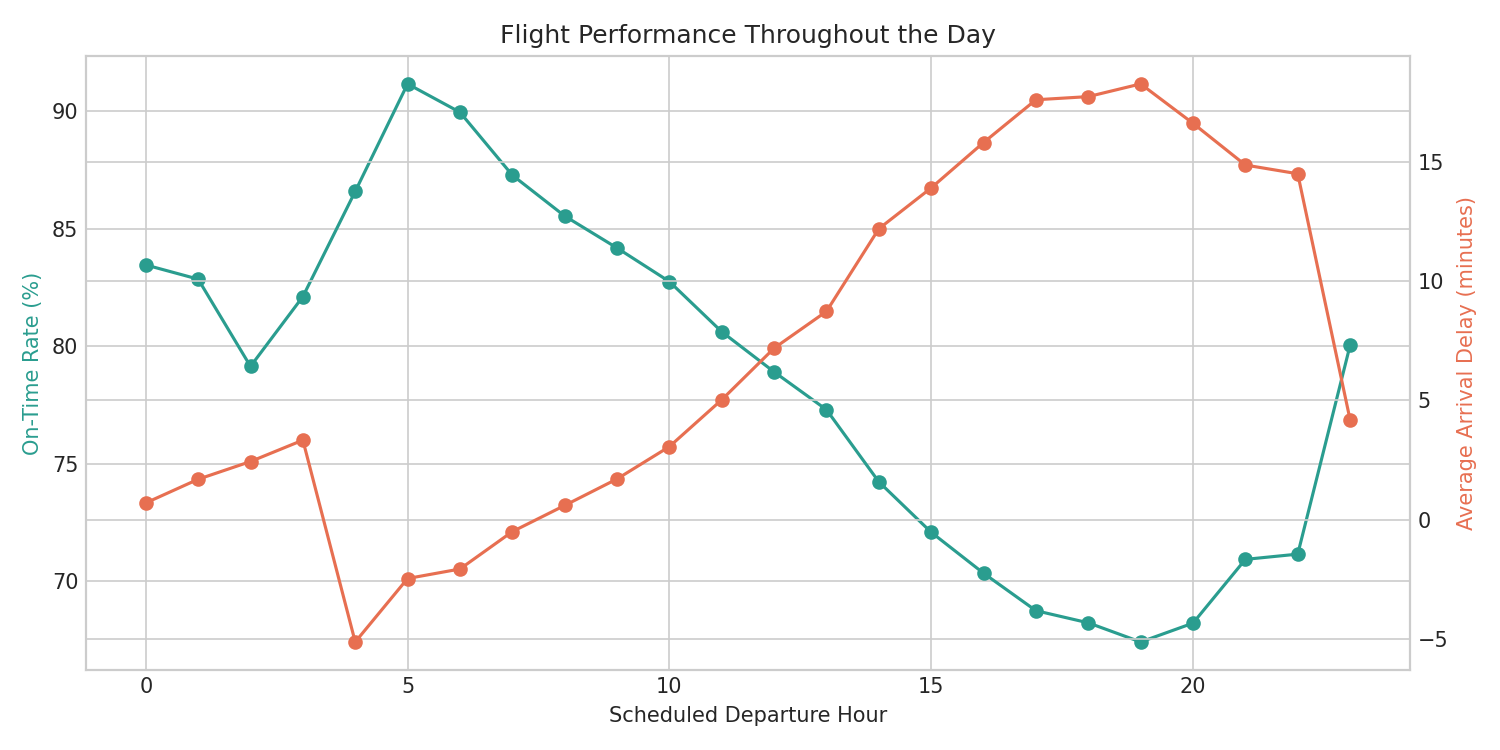

In [11]:
hourly = summaries["departure_hour"].sort_values("departure_hour")

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(hourly["departure_hour"], hourly["on_time_rate"], marker="o", color="#2A9D8F")
ax1.set_xlabel("Scheduled Departure Hour")
ax1.set_ylabel("On-Time Rate (%)", color="#2A9D8F")

ax2 = ax1.twinx()
ax2.plot(hourly["departure_hour"], hourly["average_arrival_delay"], marker="o", color="#E76F51")
ax2.set_ylabel("Average Arrival Delay (minutes)", color="#E76F51")

plt.title("Flight Performance Throughout the Day")
fig.tight_layout()
plt.show()

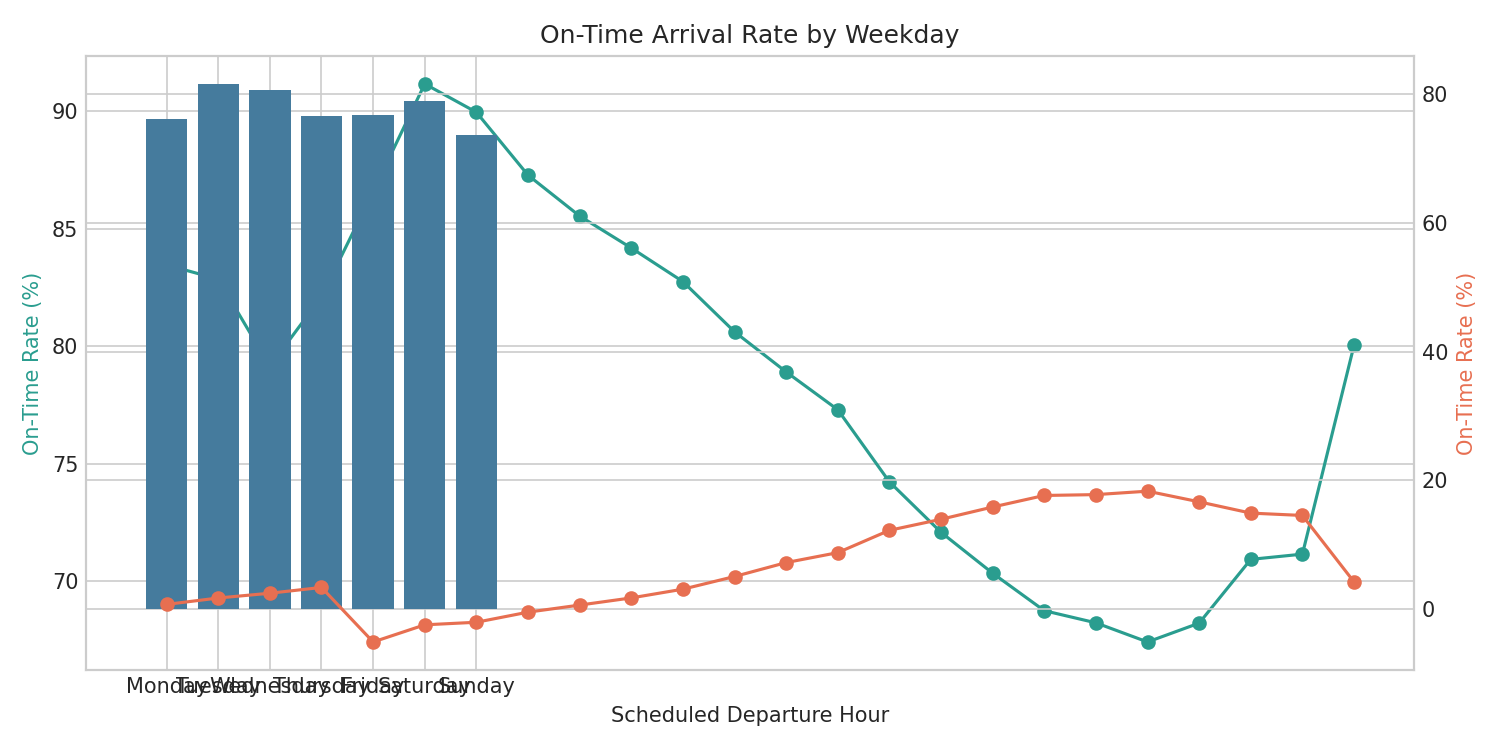

In [12]:
weekday_names = {
    1: "Monday", 2: "Tuesday", 3: "Wednesday", 4: "Thursday",
    5: "Friday", 6: "Saturday", 7: "Sunday"
}

weekdays = summaries["weekday"].sort_values("day_of_week")
weekdays["weekday"] = weekdays["day_of_week"].map(weekday_names)

plt.bar(weekdays["weekday"], weekdays["on_time_rate"], color="#457B9D")
plt.title("On-Time Arrival Rate by Weekday")
plt.ylabel("On-Time Rate (%)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [13]:
time_periods = summaries["time_of_day"].sort_values("on_time_rate", ascending=False)
time_periods[["time_of_day", "total_flights", "on_time_rate", "average_arrival_delay", "cancellation_rate"]].round(2)

## 7. Delay causes

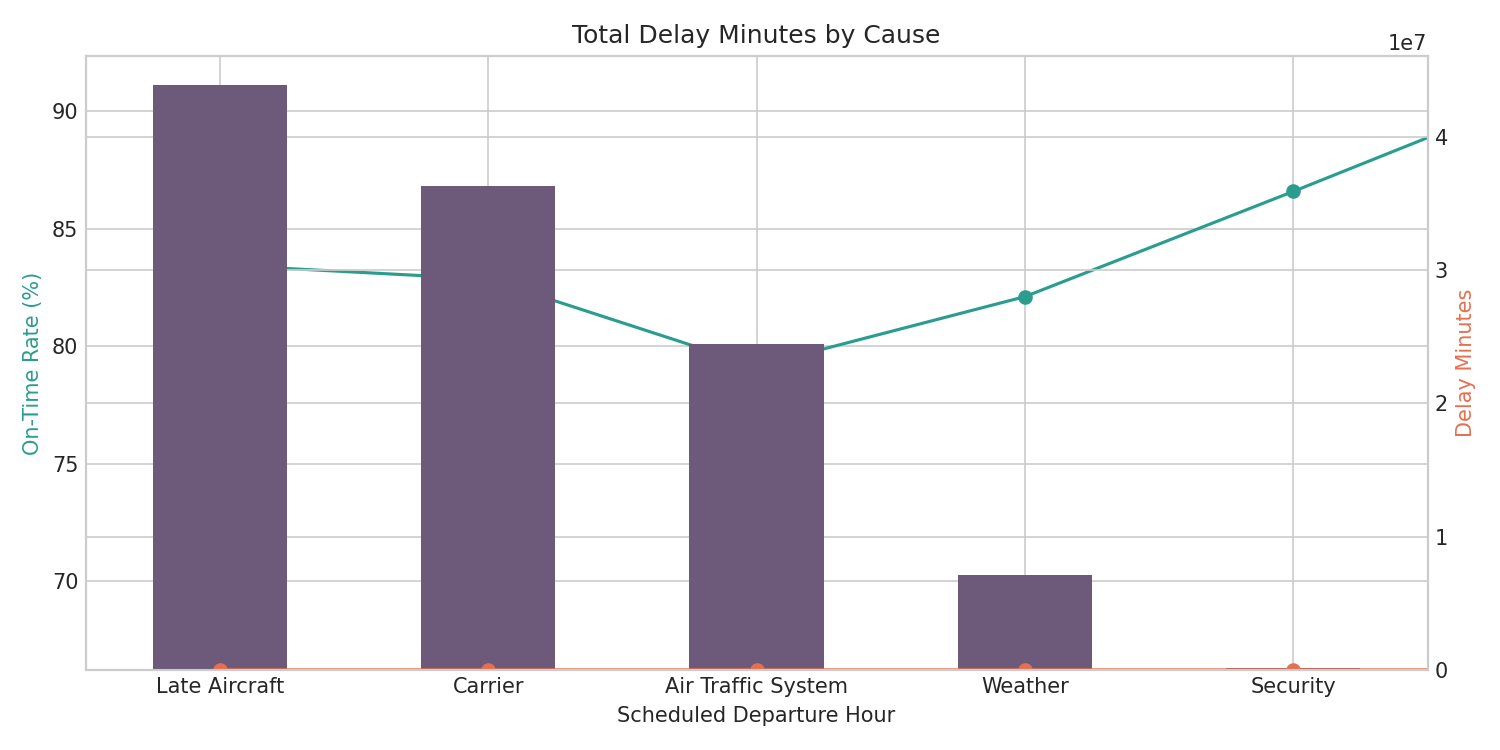

In [14]:
cause_columns = {
    "Carrier": "carrier_delay",
    "Weather": "weather_delay",
    "Air Traffic System": "n_a_s_delay",
    "Security": "security_delay",
    "Late Aircraft": "late_aircraft_delay",
}

delay_causes = pd.Series({name: overall[column] for name, column in cause_columns.items()})
delay_causes = delay_causes.sort_values(ascending=False)

delay_causes.plot(kind="bar", color="#6D597A")
plt.title("Total Delay Minutes by Cause")
plt.ylabel("Delay Minutes")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

(delay_causes / delay_causes.sum() * 100).round(2).rename("Share of Cause Delay (%)")

## 8. Key findings

In [15]:
best_airline = airlines.iloc[0]
worst_airline = airlines.iloc[-1]
best_month = monthly.loc[monthly["on_time_rate"].idxmax()]
worst_month = monthly.loc[monthly["on_time_rate"].idxmin()]
best_period = time_periods.iloc[0]
worst_period = time_periods.iloc[-1]
main_cause = delay_causes.index[0]

findings = [
    f"Overall on-time arrival rate: {overall_results['On-Time Arrival Rate (%)']:.1f}%.",
    f"Best airline: {best_airline['airline_name']} ({best_airline['on_time_rate']:.1f}%).",
    f"Lowest airline result: {worst_airline['airline_name']} ({worst_airline['on_time_rate']:.1f}%).",
    f"Best month: {int(best_month['month'])} ({best_month['on_time_rate']:.1f}%).",
    f"Most difficult month: {int(worst_month['month'])} ({worst_month['on_time_rate']:.1f}%).",
    f"Most reliable time period: {best_period['time_of_day']} ({best_period['on_time_rate']:.1f}%).",
    f"Least reliable time period: {worst_period['time_of_day']} ({worst_period['on_time_rate']:.1f}%).",
    f"Largest reported delay cause: {main_cause}.",
]

for finding in findings:
    print("-", finding)

## Business recommendations

- Prioritise early departures because operational delays accumulate during the day.
- Add schedule buffers on high-risk routes and at poorly performing airports.
- Monitor aircraft turnaround time to reduce late-aircraft delays.
- Prepare more staff and operational capacity during difficult months.
- Review airlines with high cancellation rates separately from airlines with high delay rates.

These results will be used to build the Power BI dashboard.